# Imports

In [193]:
import pandas as pd
import datetime
import numpy as np
import pickle
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_tree
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [2]:
df_data = pickle.load(open(r"C:\develop\EnergyTrading\Python\Strategies\Sparsity_strategy\obt_reg_mqy.pkl", 'rb'))

In [6]:
df_data = df_data.reset_index(names='timestamp').dropna(subset=['int'])

In [8]:
df_data.columns

Index(['timestamp', 'y_0.0', 'y_0.15', 'y_0.30', 'delta_a_05', 'delta_a_20',
       'delta_b_05', 'delta_b_20', 'delta_mid_05', 'delta_mid_20',
       'ba_volrat_00', 'ba_volrat_30', 'ba_volrat_50', 'ba_volrat_90',
       'diff_am_wm_00', 'diff_am_wm_30', 'diff_am_wm_50', 'diff_am_wm_90',
       'delta_mw_00_05', 'delta_mw_30_05', 'delta_mw_50_05', 'delta_mw_90_05',
       'delta_mw_00_20', 'delta_mw_30_20', 'delta_mw_50_20', 'delta_mw_90_20',
       'b_price_sparsity', 'a_price_sparsity', 'b_price', 'a_price',
       'diff_mw00_05_20', 'diff_mw01_05_20', 'diff_mw02_05_20', '_close_level',
       '_far_level', 'trd_price', 'trd_side', 'trd_gap', 'last_trade_margin',
       'mid', 'p_movement_0.3', 'p_movement_0.5', 'p_movement_1.0', 'int'],
      dtype='object')

In [13]:
df_data = df_data[~(abs(df_data['trd_gap']) > 0.3)]

# Benchmark model

In [ ]:
l_traded_filter = lambda row: bool(row['trd_price'] > 0)

In [ ]:

filtered_test = df_test[df_test.apply(l_traded_margin, axis=1)]
filtered_train = df_train[df_train.apply(l_traded_margin, axis=1)]

# filtered_df now contains only the rows that satisfy the condition specified in the lambda function


In [22]:
l_relabel = lambda x: 2 if x > .5 else 0 if x < -.5 else 1
margin = 0.19
l_benchmark = lambda x: 1 if x > margin else -1 if x < -margin else 0
df_bmark = df_data.copy()
df_bmark['y_hat'] = df_bmark['trd_gap'].apply(l_benchmark)

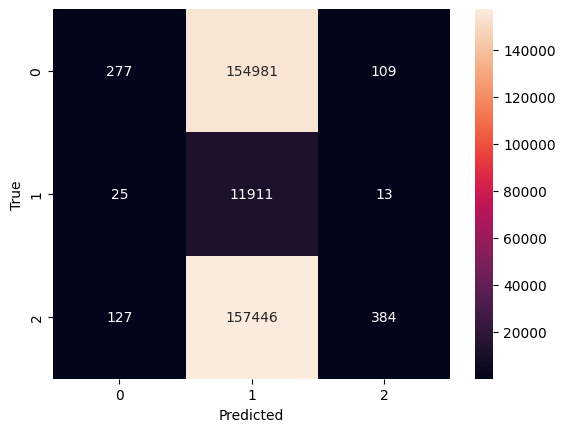

Precision: 0.758893280632411
Precision neg: 0.6456876456876457


In [190]:
cm = confusion_matrix(df_bmark['y_0.0'], df_bmark['y_hat'])

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

true_positives = cm[2, 2]  # Actual positive (1) and predicted positive (1)
false_positives = cm[0, 2] + cm[1, 2]  # Actual negative (0) but predicted positive (1)

precision = true_positives / (true_positives + false_positives)
print("Precision:", precision)

true_negative = cm[0, 0] # Actual positive (1) and predicted positive (1)
false_negative = cm[2, 0] + cm[1, 0] # Actual negative (0) but predicted positive (1)

precision = true_negative / (true_negative + false_negative)
print("Precision neg:", precision)

# XGB model

## Data prep

Filter data entries when trade occurs for the purpose of margin feature

In [17]:
l_margin_calc = lambda row: row['trd_price'] - row['a_price'] if row['trd_side'] > 0.5 else row['b_price'] - row['trd_price']
def trd_gap_calc(row):
    if bool((row['trd_price'] > (row['a_price'])) or (row['trd_price'] < (row['b_price']))):
        if row['trd_side'] > 0.5:
            return row['trd_price'] - row['a_price']
        else:
            return row['trd_price'] - row['b_price']
    else:
        return 0.0
        
l_traded_filter = lambda row: bool(row['trd_price'] > 0)

In [18]:
data_set = df_data[df_data.apply(l_traded_filter, axis=1)]
# drop entries where bid or ask price is not defined
data_set.dropna(subset=['b_price', 'a_price'], inplace=True)
# add feature margin
data_set['trd_gap'] = data_set.apply(trd_gap_calc, axis=1)

C:\Users\scasny\AppData\Local\Temp\ipykernel_18508\3968177532.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_set.dropna(subset=['b_price', 'a_price'], inplace=True)
C:\Users\scasny\AppData\Local\Temp\ipykernel_18508\3968177532.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_set['trd_gap'] = data_set.apply(trd_gap_calc, axis=1)


There is originaly label defined as [-1, 0, 1]

We want labels [0, 1] for each model (long, short)

In [19]:
l_long_relabel = lambda x: 1 if x > 0 else 0
l_short_relabel = lambda x: 1 if x < 0 else 0
l_neu_relabel = lambda x: 1 if x < 0.5 and x > -0.5 else 0

Method for spliting dataset into train and test sets

**Arguments**:
- l_func : function for relabeling
- train : int<0,100> percent in train set (test set contains [n:] entries)
- **margin_ratio** : is used for balancing dataset on margin values. Margin is negative in most cases we want to have balanced values in training set because we assume that this should be strongest predictor. Value represents portion of data with margin greater than 0.03eur to data without margin (e.g. margin_ratio = 0.3 -> margin_data = 200, no_margin_data = cca 600)

In [10]:
def dataset_split(df, l_func=None, train: int = 50, margin_ratio=0.2, balance=False):
    idx = int(np.percentile(df.index, train))
    train = df[df.index < idx].copy()
    test = df[df.index > idx].copy()
    if l_func:
        train['y'] = train['y'].apply(l_func)
        test['y'] = test['y'].apply(l_func)

    def balance_split(data, margin_ratio):
        margin_data = data[(data['margin'] > .03) & (data['margin'] < .3)]
        wo_margin_data = data[(data['margin'] < .03)]
        return pd.concat([margin_data, wo_margin_data.sample(
            frac=min(0.99, margin_data.shape[0]/margin_ratio/wo_margin_data.shape[0]))]).sample(frac=.8).set_index('timestamp').reset_index()
    
    def balance_on_y(data):
        positives = sum(data['y'] == 1)
        idxs = data[data['y'] == 0].sample(positives).index
        return data[(data.index.isin(idxs)) | (data['y'] == 1)]
    
    if balance:   
        return balance_on_y(balance_split(train, margin_ratio)), test
    else:
        return train, test

In [14]:
# 0.2 for margin_ratio is used for this experiment, can be increased but this will reduce samples in data sets
train, test = dataset_split(data_set, train=65)
train['y'].value_counts()

y
 0.0    23181
 1.0    17944
-1.0    17902
Name: count, dtype: int64

In [128]:
train[['timestamp', 'trd_gap', 'b_price_sparsity', 'a_price_sparsity', 'y' ]].describe()

,timestamp,trd_gap,b_price_sparsity,a_price_sparsity,y
count,46216,46216.000000,46216.000000,46216.000000,45574.000000
mean,2023-12-13 02:23:43.427254784,0.000946,0.285310,0.265537,-0.001931
min,2023-11-01 09:00:09,-1.650000,0.000000,0.000000,-1.000000
25%,2023-11-21 11:48:06,0.000000,0.170000,0.160000,-1.000000
50%,2023-12-12 13:40:24.500000,0.000000,0.240000,0.230000,0.000000
75%,2024-01-05 13:27:28.500000,0.000000,0.370000,0.340000,1.000000
max,2024-01-24 11:06:45,2.930000,1.000000,1.000000,1.000000
std,NaN,0.039294,0.164363,0.147085,0.767625


In [132]:
import plotly.graph_objects as go

# Filter data
filtered_data = train[abs(train['trd_gap']) > 0.05]['trd_gap']

# Create histogram trace
fig = go.Figure()
fig.add_trace(go.Histogram(x=filtered_data, xbins=dict(size=0.05)))

# Set x-axis range
fig.update_layout(xaxis=dict(range=[-0.3, 0.3]))  # Adjust the range as needed

# Show the plot
fig.show()

In [167]:
import plotly.graph_objects as go

def precision_curve(model, grid, train_data, test_data, feature_cols, l_func): 
    # Predict probabilities for train and test data
    train_preds_p = model.predict_proba(train_data[feature_cols])
    test_preds_p = model.predict_proba(test_data[feature_cols])
    
    # Threshold for more certainty in predicted values
    thold_list = np.linspace(0.3, 0.9, grid)
    
    # Initialize results dictionaries for train and test data
    train_result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
    test_result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
    
    # Calculate precision and recall for train data
    for thold in thold_list:
        train_preds = [(lambda x: 1 if x > thold else 0)(x[1]) for x in train_preds_p]
        cm = confusion_matrix(train_data['y'].apply(l_func), train_preds)
        
        true_positives = cm[1, 1]
        false_positives = cm[0, 1]
        false_negatives = cm[1, 0]

        precision = true_positives / (true_positives + false_positives)
        recall = true_positives / (true_positives + false_negatives)
        
        train_result['thold'].append(thold)
        train_result['precision'].append(precision)
        train_result['recall'].append(recall)
        train_result['count'].append(true_positives + false_positives)
    
    # Calculate precision and recall for test data
    for thold in thold_list:
        test_preds = [(lambda x: 1 if x > thold else 0)(x[1]) for x in test_preds_p]
        cm = confusion_matrix(test_data['y'].apply(l_func), test_preds)
        
        true_positives = cm[1, 1]
        false_positives = cm[0, 1]
        false_negatives = cm[1, 0]

        precision = true_positives / (true_positives + false_positives)
        recall = true_positives / (true_positives + false_negatives)
        
        test_result['thold'].append(thold)
        test_result['precision'].append(precision)
        test_result['recall'].append(recall)
        test_result['count'].append(true_positives + false_positives)
    
    # Create Plotly traces for train and test data
    train_trace = go.Scatter(x=train_result['count'], y=train_result['precision'], mode='lines', name='Train Data')
    test_trace = go.Scatter(x=test_result['count'], y=test_result['precision'], mode='lines', name='Test Data')
    
    # Store the traces in a list
    traces = [train_trace, test_trace]
    
    return traces, (max_depth, n_estimators)


In [159]:
def precision_curve(model, data, l_func): 
    preds_p = model.predict_proba(data[feature_cols])
    # threshold for more certainty in predicted values
    thold_list = np.arange(0.3, 0.9, 0.005)
    result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
    for thold in thold_list:
        preds = [(lambda x: 1 if x > thold else 0)(x[1]) for x in preds_p]
        cm = confusion_matrix(data['y'].apply(l_func), preds)
        
        true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
        false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
        false_negatives = cm[1, 0]

        precision = true_positives / (true_positives + false_positives)
        recall = true_positives / (true_positives + false_negatives)
        result['thold'].append(thold)
        result['precision'].append(precision)
        result['recall'].append(recall)
        result['count'].append(true_positives + false_positives)
    prec_df = pd.DataFrame(result)

    ax = plt.plot(prec_df['count'], prec_df['precision'])

    plt.show()

**Predictor description**

- `margin`: represents gap between traded price and best order price
- `p_movement`: is accumualating operator for mid price (t0-t1), contains value between <-1.0, 1.0>, 1.0 basically means that price is in local maximum, -1.0 the opposite.
- `b_price_sparsity, a_price_sparsity`: value between <0.0, 1.0>
- `ba_volrat_0.5`: volume ratio between bid and ask <-1.0, 1.0>
- `mid_priceW_0.5`: weighted mid price, value that is centered around 0.0, when there is more volume on bid value increases
- `diff_`: differentiated mid returns for secondary markets

In [169]:
feature_cols = [
    'trd_gap',
    'p_movement',
    'b_price_sparsity',
    'a_price_sparsity',
    'ba_spread',
    'ba_volrat_0.5', 
    'mid_priceW_0.5',
    'diff_de_q',
    'diff_de_y',
    'diff_ttf_m'
]
# List to store traces for different parameter combinations
all_traces = []

# Iterate over different combinations of parameters
for max_depth in [3, 5, 7]:
    for n_estimators in [5, 7, 10]:
        # Train the model with the current parameters
        model = XGBClassifier(max_depth=max_depth, n_estimators=n_estimators)
        model.fit(train[feature_cols],
              train['y'].apply(l_short_relabel), eval_metric='logloss')
        
        # Calculate precision curve for train and test data
        traces = precision_curve(model, 20, train, test, feature_cols, l_short_relabel)
        
        # Add the traces to the list
        all_traces.extend(traces)

# Create Plotly figure with traces
fig = go.Figure(data=all_traces)

# Add sliders for parameter selection
# Add layout, axis labels, and other properties as needed

steps = []
for i, max_depth in enumerate([3, 5, 7]):
    for j, n_estimators in enumerate([50, 100, 150]):
        step = dict(
            method="update",
            args=[{"visible": [False] * len(all_traces)}],
            label=f"Max Depth: {max_depth}, n_estimators: {n_estimators}",
        )
        step["args"][0]["visible"][i * 3 + j] = True  # Show the corresponding traces
        steps.append(step)

sliders = [dict(
    active=0,
    currentvalue={"prefix": "Parameter Combination: "},
    pad={"t": 50},
    steps=steps
)]

fig.update_layout(sliders=sliders)

# Add layout, axis labels, and other properties as needed

# Show the plot
fig.show()

C:\develop\EnergyTrading\env\Lib\site-packages\xgboost\sklearn.py:889: UserWarning:

`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:24: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:24: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:24: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:24: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:24: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:24: RuntimeWarning:

invalid value encountere

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:41: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:41: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:41: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\develop\EnergyTrading\env\Lib\site-packages\xgboost\sklearn.py:889: UserWarning:

`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:24: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:24: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:24: RuntimeWarning:

invalid value encountere

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:24: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:41: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:41: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:41: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:41: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2820758185.py:41: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\develop\EnergyTrading\env\Lib\site-packages\xgboost\sklearn.py:889: UserWarning:

`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or

ValueError: 
    Invalid element(s) received for the 'data' property of 
        Invalid elements include: [[Scatter({
    'mode': 'lines',
    'name': 'Train Data',
    'x': [26069, 17800, 8285, 2107, 249, 56, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0],
    'y': [0.3760788676205455, 0.4117977528089888, 0.4494870247435124,
          0.4997626957759848, 0.5903614457831325, 0.6607142857142857,
          0.5714285714285714, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan]
}), Scatter({
    'mode': 'lines',
    'name': 'Test Data',
    'x': [20987, 14719, 7243, 1250, 108, 14, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0],
    'y': [0.37909181874493736, 0.3890889326720565, 0.3985917437525887, 0.416,
          0.3888888888888889, 0.5, 0.5, nan, nan, nan, nan, nan, nan, nan, nan,
          nan, nan, nan, nan, nan]
})], (3, 5), [Scatter({
    'mode': 'lines',
    'name': 'Train Data',
    'x': [25834, 18427, 9355, 3193, 747, 258, 104, 31, 4, 1, 0, 0, 0,

C:\develop\EnergyTrading\env\Lib\site-packages\xgboost\sklearn.py:889: UserWarning:

`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.



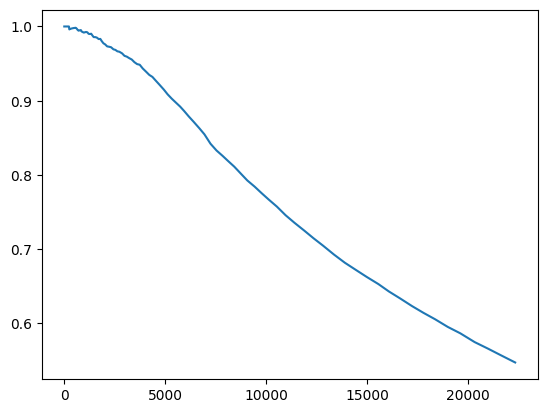

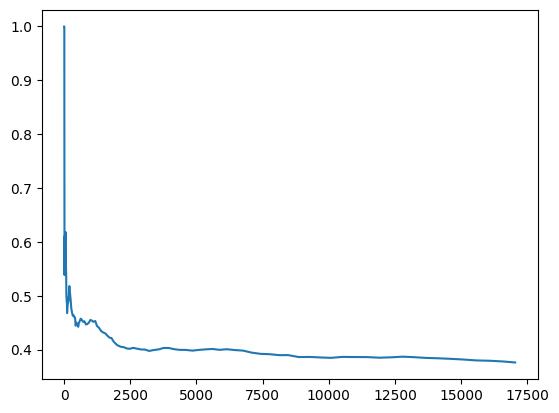

In [161]:
feature_cols = [
    'trd_gap',
    'p_movement',
    'b_price_sparsity',
    'a_price_sparsity',
    'ba_spread',
    'ba_volrat_0.5', 
    'mid_priceW_0.5',
    'diff_de_q',
    'diff_de_y',
    'diff_ttf_m'
]
xgb_model = XGBClassifier(max_depth=10, n_estimators=10)
xgb_model.fit(train[feature_cols],
              train['y'].apply(l_short_relabel), eval_metric='logloss')
precision_curve(xgb_model, train, l_short_relabel)
precision_curve(xgb_model, test, l_short_relabel)

In [229]:
import plotly.graph_objects as go
l_func = l_short_relabel

def precision_curve(model, grid, train_data, test_data, feature_cols, l_func, max_depth, n_estimators): 
    # Calculate precision curves for train and test data
    # This part should be same as before
        # Predict probabilities for train and test data
    train_preds_p = model.predict_proba(train_data[feature_cols])
    test_preds_p = model.predict_proba(test_data[feature_cols])
    
    # Threshold for more certainty in predicted values
    thold_list = np.linspace(0.3, 0.9, grid)
    
    # Initialize results dictionaries for train and test data
    train_result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
    test_result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
    
    # Calculate precision and recall for train data
    for thold in thold_list:
        train_preds = [(lambda x: 1 if x > thold else 0)(x[1]) for x in train_preds_p]
        cm = confusion_matrix(train_data['y'].apply(l_func), train_preds)
        
        true_positives = cm[1, 1]
        false_positives = cm[0, 1]
        false_negatives = cm[1, 0]

        precision = true_positives / (true_positives + false_positives)
        recall = true_positives / (true_positives + false_negatives)
        
        train_result['thold'].append(thold)
        train_result['precision'].append(precision)
        train_result['recall'].append(recall)
        train_result['count'].append(true_positives + false_positives)
    
    # Calculate precision and recall for test data
    for thold in thold_list:
        test_preds = [(lambda x: 1 if x > thold else 0)(x[1]) for x in test_preds_p]
        cm = confusion_matrix(test_data['y'].apply(l_func), test_preds)
        
        true_positives = cm[1, 1]
        false_positives = cm[0, 1]
        false_negatives = cm[1, 0]

        precision = true_positives / (true_positives + false_positives)
        recall = true_positives / (true_positives + false_negatives)
        
        test_result['thold'].append(thold)
        test_result['precision'].append(precision)
        test_result['recall'].append(recall)
        test_result['count'].append(true_positives + false_positives)
    # Create Plotly traces for train and test data
    train_trace = go.Scatter(
        x=train_result['count'], 
        y=train_result['precision'], 
        mode='lines', 
        name=f'Train Data (Max Depth: {max_depth}, n_estimators: {n_estimators})'
    )
    test_trace = go.Scatter(
        x=test_result['count'], 
        y=test_result['precision'], 
        mode='lines', 
        name=f'Test Data (Max Depth: {max_depth}, n_estimators: {n_estimators})'
    )
    
    # Store the traces in a list along with the parameter combination
    traces = [train_trace, test_trace]
    
    return traces, (max_depth, n_estimators)

# Create empty lists to store traces and steps
all_traces = []
steps = []

# Iterate over different combinations of parameters
for max_depth in [3, 5]:
    for n_estimators in [5, 7]:
        # Train the model with the current parameters
        model = XGBClassifier(max_depth=max_depth, n_estimators=n_estimators)
        model.fit(train[feature_cols], train['y'].apply(l_func))
        
        # Calculate precision curve for train and test data
        traces, params = precision_curve(model, 10, train, test, feature_cols, l_func, max_depth, n_estimators)
        
        # Add the traces to the list
        all_traces.extend(traces)
        
        # Create step for the slider
        step = dict(
            method="update",
            args=[{"visible": [params == p for p in params]}],
            label=f"Max Depth: {max_depth}, n_estimators: {n_estimators}",
        )
        steps.append(step)

# Create sliders
max_depth_slider = dict(
    active=0,
    steps=steps,
    name="Max Depth"
)

n_estimators_slider = dict(
    active=0,
    steps=steps,
    name="n_estimators"
)

# Create layout with sliders
layout = dict(sliders=[max_depth_slider, n_estimators_slider])

# Create Plotly figure with traces and layout
fig = go.Figure(data=all_traces, layout=layout)

fig.update_layout(
    sliders=sliders
)
# Show the plot
fig.show()


C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2886205383.py:27: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2886205383.py:27: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2886205383.py:27: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2886205383.py:27: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2886205383.py:27: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2886205383.py:27: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2886205383.py:27: RuntimeWarning:

invalid value encountered in longlong_scalars

C:\Users\scasny\AppData\Local\Temp\ipykernel_9356\2886205383.py:44: RuntimeW

In [187]:
dir(fig)

['__class__',
 '__contains__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_annotation_like',
 '_allow_disable_validation',
 '_animation_duration_validator',
 '_animation_easing_validator',
 '_batch_layout_edits',
 '_batch_trace_edits',
 '_bracket_re',
 '_build_dispatch_plan',
 '_build_update_params_from_batch',
 '_config',
 '_data',
 '_data_defaults',
 '_data_objs',
 '_data_validator',
 '_dispatch_layout_change_callbacks',
 '_dispatch_trace_change_callbacks',
 '_filter_by_selector',
 '_frame_objs',
 '_frames_validator',
 '_get_child_prop_defaults',
 '_get_child_props',
 '_get_subplot_coordinates',
 '_get_subplot

<Axes: >

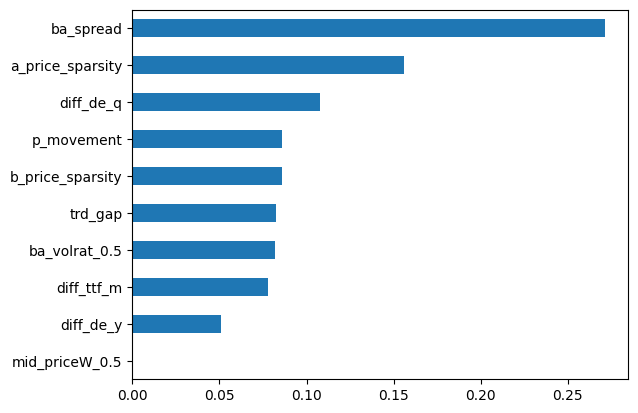

In [134]:
feat_importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)
feat_importances.sort_values().plot(kind='barh')

**Confusion matrix**

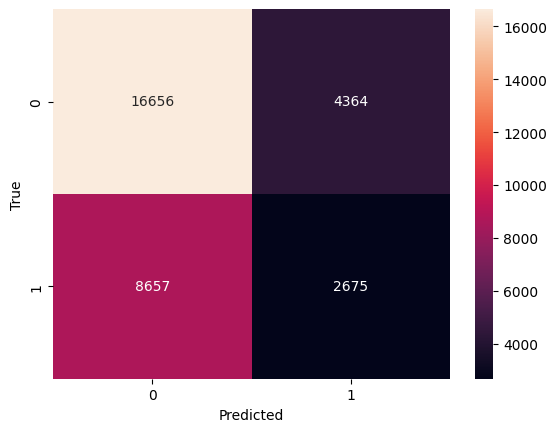

Precision long: 0.3800255718141782
Recall long: 0.2360571831980233
Score ratio: 0.21757542037586547


In [137]:
threshold = 0.45
preds = [(lambda x: 1 if x > threshold else 0)(x[1]) for x in preds_]

cm = confusion_matrix(test['y'].apply(l_short_relabel), preds)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
false_negatives = cm[1, 0]

precision = true_positives / (true_positives + false_positives)
print("Precision long:", precision)

recall = true_positives / (true_positives + false_negatives)
print("Recall long:", recall)
skore_ratio = (cm[1, 1] + cm[0, 1]) / (cm[1, 1] + cm[0, 1] + cm[1, 0] + cm[0, 0])
print("Score ratio:", skore_ratio)

**Shap values**

C:\develop\EnergyTrading\env\Lib\site-packages\shap\explainers\_tree.py:664: RuntimeWarning: invalid value encountered in divide
  if np.max(diff / (np.abs(sum_val) + 1e-2)) > 1e-2:


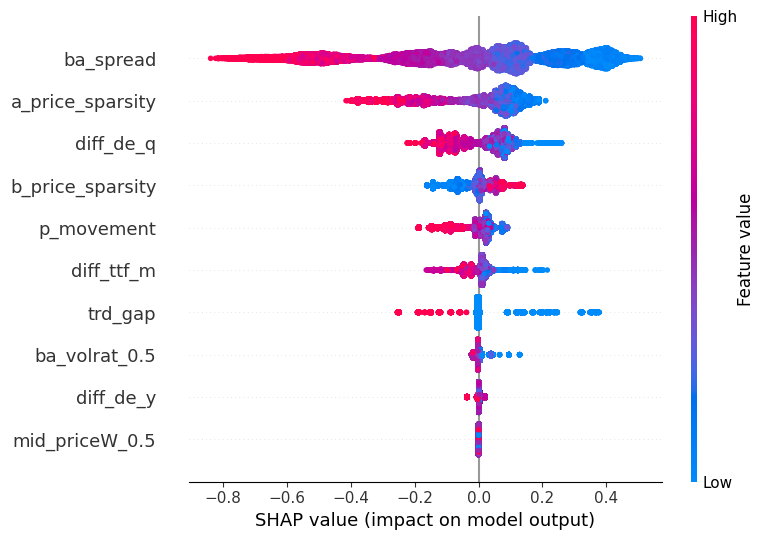

In [86]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(train[feature_cols])
shap.summary_plot(shap_values, train[feature_cols])

In [ ]:
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')

## **Precision curve**

In [151]:
preds_p = xgb_model.predict_proba(test[feature_cols])
# threshold for more certainty in predicted values
thold_list = np.arange(0.4, 0.95, 0.005)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [(lambda x: 1 if x > thold else 0)(x[1]) for x in preds_p]
    cm = confusion_matrix(test['y'].apply(l_short_relabel), preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

### No balance data

SHORT curve

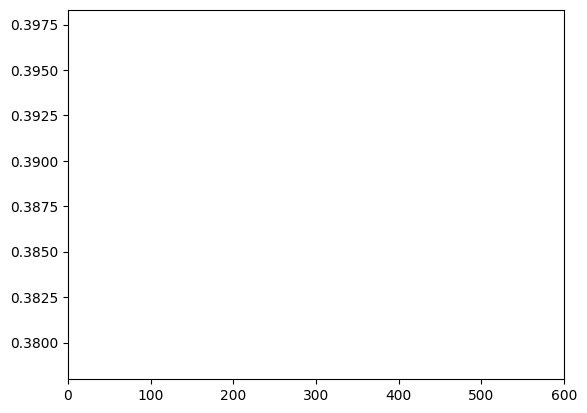

In [145]:
ax = plt.plot(prec_recall_df['count'], prec_recall_df['precision'])
plt.xlim(right=600)  # Set the right limit of the x-axis to 1000
plt.xlim(left=0) # Set the right limit of the x-axis to 1000
plt.show()

In [146]:
prec_recall_df[(prec_recall_df['count'] < 150) & (prec_recall_df['count'] > 50)]

,thold,precision,recall,count


### Train curve

In [153]:
preds_p = xgb_model.predict_proba(train[feature_cols])
# threshold for more certainty in predicted values
thold_list = np.arange(0.3, 0.9, 0.005)
result = {'thold': [], 'precision': [], 'recall': [], 'count': []}
for thold in thold_list:
    preds = [(lambda x: 1 if x > thold else 0)(x[1]) for x in preds_p]
    cm = confusion_matrix(train['y'].apply(l_short_relabel), preds)
    
    true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
    false_negatives = cm[1, 0]

    precision = true_positives / (true_positives + false_positives)
    recall = true_positives / (true_positives + false_negatives)
    result['thold'].append(thold)
    result['precision'].append(precision)
    result['recall'].append(recall)
    result['count'].append(true_positives + false_positives)
prec_recall_df = pd.DataFrame(result)

In [154]:
prec_recall_df[(prec_recall_df['count'] < 200) & (prec_recall_df['count'] > 50)]

,thold,precision,recall,count


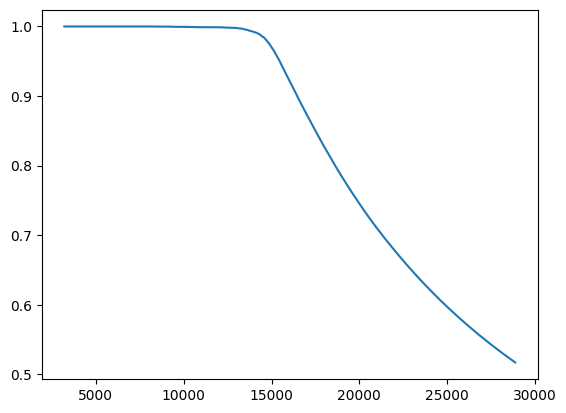

In [155]:
ax = plt.plot(prec_recall_df['count'], prec_recall_df['precision'])

plt.show()

# Model combination

In [18]:
xgb_model_long = XGBClassifier(max_depth=3, n_estimators=10)
xgb_model_long.fit(train[feature_cols],
              train['y'].apply(l_long_relabel), eval_metric='logloss')
preds_long = xgb_model_long.predict_proba(test[feature_cols])

xgb_model_short = XGBClassifier(max_depth=3, n_estimators=10)
xgb_model_short.fit(train[feature_cols],
              train['y'].apply(l_short_relabel), eval_metric='logloss')
preds_short = xgb_model_short.predict_proba(test[feature_cols])

xgb_model_neu = XGBClassifier(max_depth=3, n_estimators=10)
xgb_model_neu.fit(train[feature_cols],
              train['y'].apply(l_neu_relabel), eval_metric='logloss')
preds_neu = xgb_model_neu.predict_proba(test[feature_cols])

C:\develop\EnergyTrading\env\Lib\site-packages\xgboost\sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
C:\develop\EnergyTrading\env\Lib\site-packages\xgboost\sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
C:\develop\EnergyTrading\env\Lib\site-packages\xgboost\sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(


In [292]:
print('sdfsf')

In [28]:
preds_comb = [(lambda p: [x/sum(p) for x in p])(p) for p in np.stack((preds_short[:,1], preds_neu[:,1], preds_long[:,1]), axis=1)]
l_relabel_comb = lambda x: 2 if x > 0.5 else 0 if x < -0.5 else 1
thold_list = np.arange(0.3, 0.6, 0.01)
result = {'thold': [], 'p_short': [], 'p_neu': [], 'p_long': [], 'count': []}
for thold in thold_list:
#     preds = [(lambda x: 1 if x > thold else 0)(x[1]) for x in preds_p]
    l_idx_max = lambda x, t: pd.Series(x).idxmax() if pd.Series(x).max() > t else 1
    preds = [l_idx_max(x, thold) for x in preds_comb]
    cm = confusion_matrix(test['y'].apply(l_relabel_comb), preds)
    
    long_TP = cm[2, 2]  # Actual positive (1) and predicted positive (1)
    long_FP = cm[0, 2] + cm[1, 2] # Actual negative (0) but predicted positive (1)
    
    short_TP = cm[0, 0]  # Actual positive (1) and predicted positive (1)
    short_FP = cm[1, 0] + cm[2, 0] # Actual negative (0) but predicted positive (1)
    
    neu_TP = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    neu_FP = cm[0, 1] + cm[2, 1] # Actual negative (0) but predicted positive (1)

    long_precision = long_TP / (long_TP + long_FP) if (long_TP + long_FP) > 0 else 0
    short_precision = short_TP / (short_TP + short_FP) if (short_TP + short_FP) > 0 else 0
    neu_precision = neu_TP / (neu_TP + neu_FP) if (neu_TP + neu_FP) > 0 else 0


    result['thold'].append(thold)
    result['p_short'].append(short_precision)
    result['p_neu'].append(neu_precision)
    result['p_long'].append(long_precision)
    result['count'].append(long_TP+long_FP+short_TP+short_FP)
prec_recall_df = pd.DataFrame(result)

In [305]:
prec_recall_df

,thold,precision,recall,count
0,0.100,0.516937,0.999933,28872
1,0.105,0.530026,0.999933,28159
2,0.110,0.543399,0.999933,27466
3,0.115,0.555518,0.999866,26865
4,0.120,0.569531,0.999866,26204
...,...,...,...,...
155,0.875,1.000000,0.272344,4065
156,0.880,1.000000,0.257269,3840
157,0.885,1.000000,0.241324,3602
158,0.890,1.000000,0.227522,3396


# Model trades data

In [1]:
dataset_df = pickle.load(open("C:\develop\EnergyTrading\Python\Strategies\Sparsity_strategy\ob_trd_secmkts_nov23-may24.pkl", 'rb'))

NameError: name 'pickle' is not defined

In [ ]:
sns.regplot(df_train, x='bids_sparsity', y='y')

In [ ]:
df_train[df_train['bids_sparsity'] > 2]

## Trade side analysis

market reaction after side disbalance

In [ ]:
day = df_train[df_train.index.date == pd.to_datetime("2023-08-01").date()]

In [ ]:
df_train['v_side'] = df_train['trd_vol']

In [ ]:
sides_dict = {
    'date': [],
    'sell': [],
    'buy': [],
    'price_diff': [],
    'v_sell': [],
    'v_buy': [],
    
}
for d in pd.Series(df_train.index.date).unique():
    day_df = df_train[df_train.index.date == d]
    sides_dict['date'].append(d)
    sides_dict['sell'].append(day_df['trd_side'].value_counts()[0])
    sides_dict['buy'].append(day_df['trd_side'].value_counts()[1])
    sides_dict['v_sell'].append(day_df[day_df['trd_side'] < 0.5]['trd_vol'].sum())
    sides_dict['v_buy'].append(day_df[day_df['trd_side'] > 0.5]['trd_vol'].sum())
    sides_dict['price_diff'].append(day_df.iloc[-1]['mid_price'] - day_df.iloc[0]['mid_price'])

In [ ]:
sides_df = pd.DataFrame(sides_dict)

In [ ]:
import plotly.express as px

In [ ]:
import plotly.graph_objects as go

# Assuming sides_df is your DataFrame

# Create the figure
fig = go.Figure()

# Add bars for buy trades
fig.add_trace(go.Bar(
    x=sides_df.index.tolist(),
    y=sides_df['v_buy'],
    name='Buy',
    marker_color='blue',
    opacity=0.6,
    offset=0,  # Set the offset to 0 for buy trades
))

# Add bars for sell trades
fig.add_trace(go.Bar(
    x=sides_df.index.tolist(),
    y=sides_df['v_sell'],
    name='Sell',
    marker_color='red',
    opacity=0.6,
    offset=-0.2,  # Set a slight offset to overlap with buy bars
))

# Add line trace for price_diff column
fig.add_trace(go.Scatter(
    x=sides_df.index.tolist(),
    y=sides_df['price_diff'],
    mode='lines',
    name='Price Difference',
    line=dict(color='green', width=2),
    yaxis='y2'  # Plot the line trace on a secondary y-axis
))

# Update layout
fig.update_layout(
    barmode='overlay',
    yaxis=dict(title='Volume'),
    yaxis2=dict(title='Price Difference', overlaying='y', side='right')  # Secondary y-axis for the line trace
)


# Show the plot
fig.show()


In [245]:
train

,timestamp,ba_spread,b_price,a_price,mid_price,ba_volrat_0.5,mid_priceW_0.5,b_price_sparsity,a_price_sparsity,p_movement,...,trd_vol,trd_side,last_trd_p,bid_t1,ask_t1,diff_de_q,diff_de_y,diff_ttf_m,trd_gap,y_l
40996,2023-11-03 14:27:58,0.004734,96.93,97.39,97.160,-0.333333,0.076667,0.58,0.22,-0.030625,...,1.0,0.0,97.10,False,False,-0.002637,-0.002022,-0.004504,0.0,0
942415,2024-02-09 11:24:26,0.002366,63.32,63.47,63.395,0.000000,0.000000,0.10,0.06,0.340278,...,1.0,1.0,63.45,True,True,-0.000174,0.000486,0.000564,0.0,0
820049,2024-01-25 13:08:59,0.001006,69.58,69.65,69.615,0.333333,-0.011667,0.15,0.26,-0.210069,...,2.0,1.0,69.63,False,True,-0.000229,0.000940,-0.003093,0.0,0
595697,2023-12-29 09:08:24,0.007463,94.78,95.49,95.135,0.333333,-0.118333,0.31,0.34,-0.886736,...,5.0,0.0,95.00,True,True,0.000476,-0.000262,0.012419,0.0,0
935601,2024-02-08 14:19:37,0.000915,65.55,65.61,65.580,0.000000,0.000000,0.19,0.31,0.000625,...,1.0,0.0,65.55,True,True,0.000827,-0.000081,0.002093,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
617194,2024-01-03 09:30:45,0.000975,92.25,92.34,92.295,0.500000,-0.022500,0.28,0.32,0.105625,...,5.0,0.0,92.25,True,False,0.008027,0.007357,0.002875,0.0,1
262173,2023-11-27 12:15:00,0.000515,97.15,97.20,97.175,-0.142857,0.003571,0.43,0.12,1.000000,...,1.0,1.0,97.20,True,True,-0.000339,0.001878,0.001315,0.0,0
55282,2023-11-06 15:06:23,0.001313,91.35,91.47,91.410,0.000000,0.000000,0.26,0.41,-0.795069,...,1.0,1.0,91.45,True,False,-0.000428,0.000140,-0.000625,0.0,0
759803,2024-01-18 12:54:48,0.000948,73.81,73.88,73.845,-0.500000,0.017500,0.24,0.18,0.146944,...,1.0,0.0,73.81,False,False,0.001724,0.005034,-0.000713,0.0,1


# Rolling training

## dataset filters

In [191]:
data_set_filtered = data_set[data_set['hour'].apply(lambda x: False if x == 9 or x == 17 else True)]


NameError: name 'data_set' is not defined

In [31]:
def df_days_tag(df):
    unique_dates = df['timestamp'].dt.date.unique()
    
    # Create a dictionary to map unique dates to tags
    date_to_tag = {date: tag for tag, date in enumerate(unique_dates)}
    
    # Add a new column for the tags
    df['day'] = df['timestamp'].dt.date.map(date_to_tag)
    
    return df.copy()
tagged_df = df_days_tag(df_data).copy()

C:\Users\scasny\AppData\Local\Temp\ipykernel_30456\4158580552.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day'] = df['timestamp'].dt.date.map(date_to_tag)


In [165]:
train_days = 20
test_days = 1
step = 1
max_day = tagged_df.day.max()
data_set_dict = {range_tuple: {} for range_tuple in [
    (train_start, train_start+(train_days-1), train_start+(train_days+test_days-1)) for train_start in range(
        0, max_day-(train_days+test_days), step)]}
for date_tuple in data_set_dict.keys():
    train_range = range(date_tuple[0], date_tuple[1]+1)
    test_range = range(date_tuple[1]+1, date_tuple[2]+1)

    data_set_dict[date_tuple]['train'] = tagged_df[tagged_df['day'].isin(train_range)]
    data_set_dict[date_tuple]['test'] = tagged_df[tagged_df['day'].isin(test_range)]

In [33]:
df_data.columns

Index(['timestamp', 'y_0.0', 'y_0.15', 'y_0.30', 'delta_a_05', 'delta_a_20',
       'delta_b_05', 'delta_b_20', 'delta_mid_05', 'delta_mid_20',
       'ba_volrat_00', 'ba_volrat_30', 'ba_volrat_50', 'ba_volrat_90',
       'diff_am_wm_00', 'diff_am_wm_30', 'diff_am_wm_50', 'diff_am_wm_90',
       'delta_mw_00_05', 'delta_mw_30_05', 'delta_mw_50_05', 'delta_mw_90_05',
       'delta_mw_00_20', 'delta_mw_30_20', 'delta_mw_50_20', 'delta_mw_90_20',
       'b_price_sparsity', 'a_price_sparsity', 'b_price', 'a_price',
       'diff_mw00_05_20', 'diff_mw01_05_20', 'diff_mw02_05_20', '_close_level',
       '_far_level', 'trd_price', 'trd_side', 'trd_gap', 'last_trade_margin',
       'mid', 'p_movement_0.3', 'p_movement_0.5', 'p_movement_1.0', 'int',
       'day', 'ba_spread'],
      dtype='object')

In [166]:
feature_cols = [
    'delta_a_05',
    'delta_a_20',
    'delta_b_05', 
    'delta_b_20', 
    'delta_mid_05', 
    'delta_mid_20',
    'ba_volrat_00', 
    'ba_volrat_30', 
    'ba_volrat_50', 
    'ba_volrat_90',
    'diff_am_wm_00', 
    'diff_am_wm_30', 
    'diff_am_wm_50', 
    'diff_am_wm_90',
    'delta_mw_00_05', 
    'delta_mw_30_05', 
    'delta_mw_50_05', 
    'delta_mw_90_05',
    'delta_mw_00_20', 
    'delta_mw_30_20',
    'delta_mw_50_20', 
    'delta_mw_90_20',
    'b_price_sparsity', 
    'a_price_sparsity', 
    'diff_mw00_05_20', 
    'diff_mw01_05_20', 
    'diff_mw02_05_20', 
    '_close_level',
    '_far_level', 
    'trd_side', 
    'trd_gap', 
    'last_trade_margin',
    'p_movement_0.3', 
    'p_movement_0.5', 
    'p_movement_1.0', 
    'int',
    'day',
    'ba_spread'
]

In [223]:
feature_cols = [
    'trd_gap'
]

In [255]:
from scipy.stats import percentileofscore

l_relabel_comb = lambda x: 2 if x > 0.5 else 0 if x < -0.5 else 1

def expected_value(precision, count):
    PROFIT_ = 0.2
    LOSS_ = 0.35
    return (count*precision*PROFIT_)-(count*(1-precision)*LOSS_)

def idx_max_thold(array, thold):
    best, sbest = sorted([(v, i) for i, v in enumerate(array)], reverse=True)[:2]
    return best[1] if best[0] > sbest[0] + thold else 1

def calibration_step(MAX_DEPTH, N_TREES, THOLD):
    xx = {}
    for key, data in data_set_dict.items():
        train = data['train'].copy()
        test = data['test'].copy()

        xgb_model_long = XGBClassifier(max_depth=MAX_DEPTH, n_estimators=N_TREES)
        xgb_model_long.fit(train[feature_cols],
                      train['y'].apply(l_long_relabel), eval_metric='logloss')

        train_preds_long = xgb_model_long.predict_proba(train[feature_cols])[:,1]
        preds_long = [percentileofscore(train_preds_long, x) for x in xgb_model_long.predict_proba(test[feature_cols])[:,1]]

        xgb_model_short = XGBClassifier(max_depth=MAX_DEPTH, n_estimators=N_TREES)
        xgb_model_short.fit(train[feature_cols],
                      train['y'].apply(l_short_relabel), eval_metric='logloss')

        train_preds_short = xgb_model_short.predict_proba(train[feature_cols])[:,1]
        preds_short = [percentileofscore(train_preds_short, x) for x in xgb_model_short.predict_proba(test[feature_cols])[:,1]]

        xgb_model_neu = XGBClassifier(max_depth=MAX_DEPTH, n_estimators=N_TREES)
        xgb_model_neu.fit(train[feature_cols],
                      train['y'].apply(l_neu_relabel), eval_metric='logloss')

        train_preds_neu = xgb_model_neu.predict_proba(train[feature_cols])[:,1]
        preds_neu = [percentileofscore(train_preds_neu, x) for x in xgb_model_neu.predict_proba(test[feature_cols])[:,1]]

        preds_comb = np.stack((preds_short, preds_neu, preds_long), axis=1)

        thold = THOLD
        result = {'thold': [], 'p_short': [], 'p_neu': [], 'p_long': [],'count': [], 'count_short': [],'count_long': [], 'ev': [], 'w_p': []}

        preds = [idx_max_thold(x, thold) for x in preds_comb]
        cm = confusion_matrix(test['y'].apply(l_relabel_comb), preds)

        long_TP = cm[2, 2]  # Actual positive (1) and predicted positive (1)
        long_FP = cm[0, 2] + cm[1, 2] # Actual negative (0) but predicted positive (1)

        short_TP = cm[0, 0]  # Actual positive (1) and predicted positive (1)
        short_FP = cm[1, 0] + cm[2, 0] # Actual negative (0) but predicted positive (1)

        neu_TP = cm[1, 1]  # Actual positive (1) and predicted positive (1)
        neu_FP = cm[0, 1] + cm[2, 1] # Actual negative (0) but predicted positive (1)

        long_count = long_TP + long_FP
        short_count = short_TP + short_FP
        long_precision = long_TP / long_count if long_count > 0 else 0
        short_precision = short_TP / short_count if short_count > 0 else 0
        neu_precision = neu_TP / (neu_TP + neu_FP) if (neu_TP + neu_FP) > 0 else 0


        result['thold'].append(thold)
        result['p_short'].append(short_precision)
        result['p_neu'].append(neu_precision)
        result['p_long'].append(long_precision)
        result['count_short'].append(short_count)
        result['count_long'].append(long_count)
        result['count'].append(long_count+short_count)

        ev = expected_value(long_precision, long_count ) + expected_value(short_precision, short_count)
        result['ev'].append(ev)

        result['w_p'].append((long_precision*long_count + short_precision*short_count)/(long_count+short_count) if (long_count+short_count) > 0 else 0)


        df_max = pd.DataFrame(result)
        df_max = df_max.iloc[df_max['ev'].idxmax()].to_dict()
        xx[key] = df_max

    return {
        'ev': pd.DataFrame(xx).T['ev'].sum(),
        'w_p': pd.DataFrame(xx).T['w_p'].mean(),
        'count': pd.DataFrame(xx).T['count'].mean()}

In [232]:
import itertools
import numpy as np
from tqdm import tqdm
import warnings

# Suppress specific xgboost warning
warnings.filterwarnings(action='ignore', category=UserWarning, message="`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.")

MAX_DEPTH = [4]
N_TREES = [7]
THOLD = np.arange(70, 96, 5)

combinations = list(itertools.product(MAX_DEPTH, N_TREES, THOLD))
result = {}

# Using tqdm for progress bar
for c in tqdm(combinations, desc="Processing combinations"):
    result[c] = calibration_step(*c)


Processing combinations:   0%|                                                                   | 0/6 [00:04<?, ?it/s]


KeyboardInterrupt: 

In [174]:
result

{'thold': [90],
 'p_short': [0.0],
 'p_neu': [0.20067739204064353],
 'p_long': [0],
 'count_short': [3],
 'count_long': [0],
 'ev': [-1.0499999999999998]}

## Inspect single

In [416]:
def idx_max_thold(array, thold_for, thold_against):
    best, sbest = sorted([(v, i) for i, v in enumerate(array)], reverse=True)[:2]
    return best[1] if (best[0] > thold_for) and (sbest[0] < thold_against) else 1

In [397]:
def idx_max_thold(array, thold_for, thold_against):
    return 2 if array[2] > thold_for else 1

In [505]:
feature_cols = [
    'ba_spread',
    'ba_volrat_0.1',
    'ba_volrat_0.15',
    'ba_volrat_0.2',
    'ba_volrat_0.3',
    'ba_volrat_0.5',
    'ba_volrat_1.0',
    'mid_priceW_0.1',
    'mid_priceW_0.15',
    'mid_priceW_0.2', 
    'mid_priceW_0.3', 
    'mid_priceW_0.5', 
    'mid_priceW_1.0',
    'p_movement_0.3', 
    'p_movement_0.5', 
    'p_movement_1.0',
    'b_price_sparsity', 
    'a_price_sparsity',
    'last_hour_vol',
    'diff_de_q',
    'diff_de_y',
    'diff_ttf_m',
#     'hour',
    'last_trade_margin',
    'trd_gap'
]

train_days = 15
test_days = 1
MAX_DEPTH = 3
N_TREES = 1
THOLD_FOR = 95
THOLD_AGAINST = 20
SUBSAMPLE = 1
COLSAMPLE = 1
GAMMA = 0
MIN_CH = 0
LAMBDA = 0
ETA = 0.3

0.6466515776414509
-9.549999999999997
2.4152542372881354

In [534]:
MAX_DEPTH = 4
N_TREES = 20
THOLD_FOR = 95
THOLD_AGAINST = 15
SUBSAMPLE = 1
COLSAMPLE = 1
GAMMA = 2
MIN_CH = 2
LAMBDA = 1
ETA = 0.25
xx = {}
for key, data in data_set_dict.items():
    train = data['train'].copy()
    test = data['test'].copy()

    xgb_model_long = XGBClassifier(max_depth=MAX_DEPTH, n_estimators=N_TREES, subsample=SUBSAMPLE, colsample_bytree=COLSAMPLE,
                                  gamma=GAMMA, min_child_weight=MIN_CH, reg_lambda=LAMBDA, learning_rate=ETA)
    xgb_model_long.fit(train[feature_cols],
                  train['y'].apply(l_long_relabel), eval_metric='logloss')

    train_preds_long = xgb_model_long.predict_proba(train[feature_cols])[:,1]
    preds_long = [percentileofscore(train_preds_long, x) for x in xgb_model_long.predict_proba(test[feature_cols])[:,1]]

    xgb_model_short = XGBClassifier(max_depth=MAX_DEPTH, n_estimators=N_TREES, subsample=SUBSAMPLE, colsample_bytree=COLSAMPLE,
                                  gamma=GAMMA, min_child_weight=MIN_CH, reg_lambda=LAMBDA, learning_rate=ETA)
    xgb_model_short.fit(train[feature_cols],
                  train['y'].apply(l_short_relabel), eval_metric='logloss')

    train_preds_short = xgb_model_short.predict_proba(train[feature_cols])[:,1]
    preds_short = [percentileofscore(train_preds_short, x) for x in xgb_model_short.predict_proba(test[feature_cols])[:,1]]

    xgb_model_neu = XGBClassifier(max_depth=MAX_DEPTH, n_estimators=N_TREES, subsample=SUBSAMPLE, colsample_bytree=COLSAMPLE,
                                  gamma=GAMMA, min_child_weight=MIN_CH, reg_lambda=LAMBDA, learning_rate=ETA)
    xgb_model_neu.fit(train[feature_cols],
                  train['y'].apply(l_neu_relabel), eval_metric='logloss')

    train_preds_neu = xgb_model_neu.predict_proba(train[feature_cols])[:,1]
    preds_neu = [percentileofscore(train_preds_neu, x) for x in xgb_model_neu.predict_proba(test[feature_cols])[:,1]]

    preds_comb = np.stack((preds_short, preds_neu, preds_long), axis=1)

    thold = THOLD
    result = {'thold': [], 'p_short': [], 'p_neu': [], 'p_long': [],'count': [], 'count_short': [],'count_long': [], 'ev': [], 'w_p': []}

    preds = [idx_max_thold(x, THOLD_FOR, THOLD_AGAINST) for x in preds_comb]
    cm = confusion_matrix(test['y'].apply(l_relabel_comb), preds)

    long_TP = cm[2, 2]  # Actual positive (1) and predicted positive (1)
    long_FP = cm[0, 2] + cm[1, 2] # Actual negative (0) but predicted positive (1)

    short_TP = cm[0, 0]  # Actual positive (1) and predicted positive (1)
    short_FP = cm[1, 0] + cm[2, 0] # Actual negative (0) but predicted positive (1)

    neu_TP = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    neu_FP = cm[0, 1] + cm[2, 1] # Actual negative (0) but predicted positive (1)
    
    long_count = long_TP + long_FP
    short_count = short_TP + short_FP
    long_precision = long_TP / long_count if long_count > 0 else 0
    short_precision = short_TP / short_count if short_count > 0 else 0
    neu_precision = neu_TP / (neu_TP + neu_FP) if (neu_TP + neu_FP) > 0 else 0


    result['thold'].append(THOLD_FOR)
    result['p_short'].append(short_precision)
    result['p_neu'].append(neu_precision)
    result['p_long'].append(long_precision)
    result['count_short'].append(short_count)
    result['count_long'].append(long_count)
    result['count'].append(long_count+short_count)

    ev = expected_value(long_precision, long_count ) + expected_value(short_precision, short_count)
    result['ev'].append(ev)
    
    result['w_p'].append((long_precision*long_count + short_precision*short_count)/(long_count+short_count) if (long_count+short_count) > 0 else 0)
    

    df_max = pd.DataFrame(result)
    df_max = df_max.iloc[df_max['ev'].idxmax()].to_dict()
    xx[key] = df_max
df_res = pd.DataFrame(xx).T
df_res['count_wp'] = df_res['count']*df_res['w_p']
print("Daily Precision", df_res[df_res['count'] > 0]['w_p'].mean())
print("Overal precision", (df_res['count_wp'].sum()/df_res['count'].sum()))
print("EV sum", df_res['ev'].sum())
print("Average count", df_res['count'].mean())
print("Active days: ", sum(df_res['count'] > 0) , "/", len(data_set_dict))

Daily Precision 0.5797650576747293
Overal precision 0.5447154471544715
EV sum -30.999999999999982
Average count 5.211864406779661
Active days:  68 / 118


<Axes: >

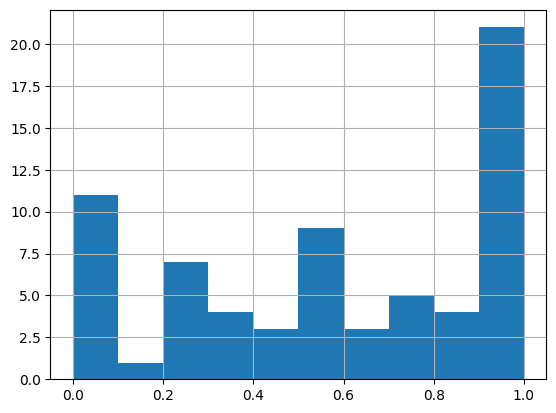

In [535]:
pd.DataFrame(xx).T.apply(lambda x: x['w_p'] if x['count'] > 0 else None, axis=1).hist()

In [448]:
df_res[df_res['count_short'] > 0].describe()

,thold,p_short,p_neu,p_long,count,count_short,count_long,ev,w_p
count,14.0,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000
mean,95.0,0.530958,0.241706,0.142857,10.071429,9.642857,0.428571,-1.128571,0.590482
std,0.0,0.421654,0.141553,0.363137,15.409609,15.603782,1.342460,3.098741,0.399154
min,95.0,0.000000,0.045174,0.000000,1.000000,1.000000,0.000000,-11.500000,0.000000
25%,95.0,0.068966,0.121869,0.000000,2.250000,1.250000,0.000000,-1.050000,0.320533
50%,95.0,0.535714,0.235454,0.000000,3.500000,3.000000,0.000000,-0.175000,0.601504
75%,95.0,1.000000,0.312314,0.000000,12.000000,11.500000,0.000000,0.200000,1.000000
max,95.0,1.000000,0.475000,1.000000,58.000000,58.000000,5.000000,0.650000,1.000000


In [420]:
df_res[df_res['count'] > 0].describe()

,thold,p_short,p_neu,p_long,count,count_short,count_long,ev,w_p
count,50.0,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,95.0,0.256582,0.270852,0.407706,11.940000,4.380000,7.560000,-0.538000,0.572904
std,0.0,0.369285,0.119437,0.421229,13.074996,10.036444,10.453317,2.231718,0.354556
min,95.0,0.000000,0.045174,0.000000,1.000000,0.000000,0.000000,-11.500000,0.000000
25%,95.0,0.000000,0.175052,0.000000,2.000000,0.000000,0.000000,-1.037500,0.357143
50%,95.0,0.000000,0.262271,0.359954,7.000000,1.000000,1.500000,-0.225000,0.554945
75%,95.0,0.528846,0.350795,0.834034,17.000000,3.000000,14.500000,0.237500,0.933824
max,95.0,1.000000,0.518987,1.000000,58.000000,58.000000,40.000000,5.150000,1.000000


In [718]:
df_res[df_res['count'] > 50]

,,,p_short,p_neu,p_long,count,count_short,count_long,ev,w_p,count_wp
8,22,23,0.517241,0.411765,0.181818,51.0,29.0,22.0,-7.40,0.372549,19.0
9,23,24,0.395349,0.404762,0.000000,53.0,43.0,10.0,-9.20,0.320755,17.0
10,24,25,0.322581,0.280000,0.342857,66.0,31.0,35.0,-11.00,0.333333,22.0
18,32,33,0.285714,0.362500,0.333333,56.0,14.0,42.0,-9.70,0.321429,18.0
30,44,45,0.307692,0.141026,0.478261,59.0,13.0,46.0,-6.35,0.440678,26.0
...,...,...,...,...,...,...,...,...,...,...,...
113,127,128,0.600000,0.111111,0.551020,94.0,45.0,49.0,-3.20,0.574468,54.0
114,128,129,0.619048,0.111111,0.352941,165.0,63.0,102.0,-16.50,0.454545,75.0
115,129,130,0.651685,0.666667,0.298246,146.0,89.0,57.0,-9.85,0.513699,75.0
116,130,131,0.414141,0.166667,0.563636,154.0,99.0,55.0,-14.30,0.467532,72.0


In [527]:
def precision_curve(data, l_func, MAX_DEPTH, N_TREES):
    model = XGBClassifier(max_depth=MAX_DEPTH, n_estimators=N_TREES)
    model.fit(data['train'][feature_cols],
                  data['train']['y'].apply(l_func), eval_metric='logloss')
    # threshold for more certainty in predicted values
    thold_list = np.arange(0.3, 0.9, 0.005)
    result = {'thold': [], 'train_precision': [], 'train_count': [],
             'test_precision': [], 'test_count': []}
    for thold in thold_list:
        result['thold'].append(thold)
        for env in ['train', 'test']:
            preds_p = model.predict_proba(data[env][feature_cols])
            preds = [(lambda x: 1 if x > thold else 0)(x[1]) for x in preds_p]
            cm = confusion_matrix(data[env]['y'].apply(l_func), preds)

            true_positives = cm[1, 1]  # Actual positive (1) and predicted positive (1)
            false_positives = cm[0, 1]  # Actual negative (0) but predicted positive (1)
            false_negatives = cm[1, 0]

            precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0

            result[env + '_' + 'precision'].append(precision)
            result[env + '_' + 'count'].append(true_positives + false_positives)

    prec_df = pd.DataFrame(result)
    ax1 = plt.plot(prec_df['train_count'], prec_df['train_precision'])
    ax2 = plt.plot(prec_df['test_count'], prec_df['test_precision'])

    plt.xlim(right=600)  # Set the right limit of the x-axis to 1000
    plt.xlim(left=0) # Set the right limit of the x-axis to 1000
    plt.show()

## Feature importance

<Axes: >

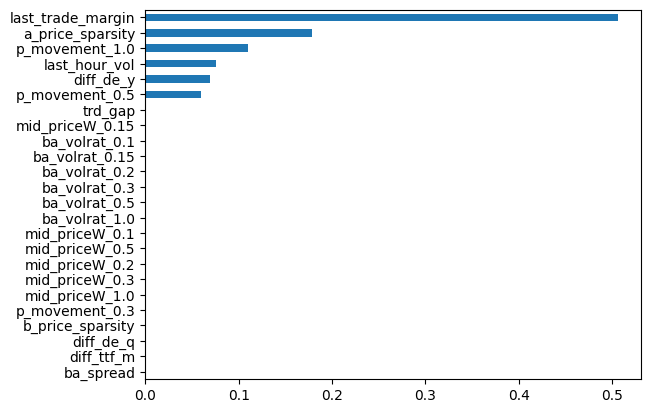

In [532]:
feat_importances = pd.Series(xgb_model_long.feature_importances_, index=feature_cols)
feat_importances.sort_values().plot(kind='barh')

<Axes: >

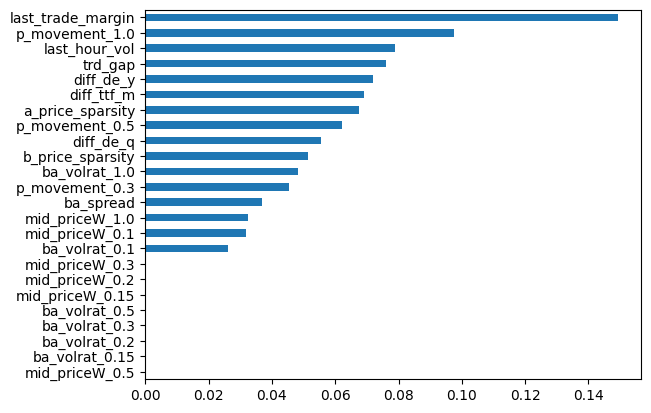

In [509]:
feat_importances = pd.Series(xgb_model_long.feature_importances_, index=feature_cols)
feat_importances.sort_values().plot(kind='barh')

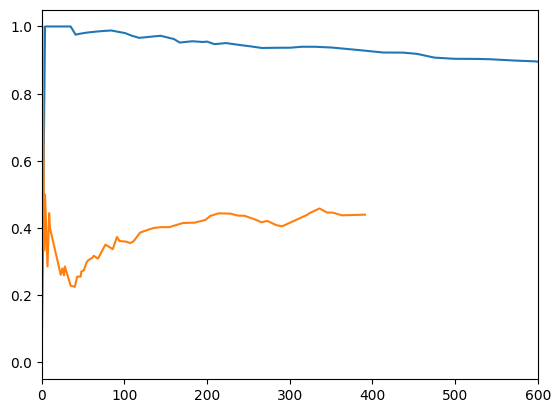

In [530]:
precision_curve(data_set_dict[(1,15,16)], l_long_relabel, 4, 20)

# Model comparison

## MAX SCORE

In [681]:
def idx_max_thold(array, thold):
    return pd.Series(array).idxmax() if max(array) > thold else 1
THOLD = 0.8
MAX_DEPTH = 5
N_TREES = 20
SUBSAMPLE = 1
COLSAMPLE = 1
GAMMA = 0
MIN_CH = 2
LAMBDA = 0
ETA = 0.3
xx = {}
heatmap = np.zeros((3,3))
for key, data in data_set_dict.items():
    train = data['train'].copy()
    test = data['test'].copy()

    xgb_model_long = XGBClassifier(objective='binary:logistic', max_depth=MAX_DEPTH, n_estimators=N_TREES, subsample=SUBSAMPLE, colsample_bytree=COLSAMPLE,
                                  gamma=GAMMA, min_child_weight=MIN_CH, reg_lambda=LAMBDA, learning_rate=ETA)
    xgb_model_long.fit(train[feature_cols],
                  train['y'].apply(l_long_relabel))

    preds_long = xgb_model_long.predict_proba(test[feature_cols])[:,1]

    xgb_model_short = XGBClassifier(objective='binary:logistic', max_depth=MAX_DEPTH, n_estimators=N_TREES, subsample=SUBSAMPLE, colsample_bytree=COLSAMPLE,
                                  gamma=GAMMA, min_child_weight=MIN_CH, reg_lambda=LAMBDA, learning_rate=ETA)
    xgb_model_short.fit(train[feature_cols],
                  train['y'].apply(l_short_relabel))

    preds_short = xgb_model_short.predict_proba(test[feature_cols])[:,1]

    xgb_model_neu = XGBClassifier(objective='binary:logistic', max_depth=MAX_DEPTH, n_estimators=N_TREES, subsample=SUBSAMPLE, colsample_bytree=COLSAMPLE,
                                  gamma=GAMMA, min_child_weight=MIN_CH, reg_lambda=LAMBDA, learning_rate=ETA)
    xgb_model_neu.fit(train[feature_cols],
                  train['y'].apply(l_neu_relabel))

    preds_neu = xgb_model_neu.predict_proba(test[feature_cols])[:,1]

    preds_comb = np.stack((preds_short, preds_neu, preds_long), axis=1)

    result = {'p_short': [], 'p_neu': [], 'p_long': [],'count': [], 'count_short': [],'count_long': [], 'ev': [], 'w_p': []}

    preds = [idx_max_thold(x, THOLD) for x in preds_comb]
    cm = confusion_matrix(test['y'].apply(l_relabel_comb), preds)
    
    long_TP = cm[2, 2]  # Actual positive (1) and predicted positive (1)
    long_FP = cm[0, 2] + cm[1, 2] # Actual negative (0) but predicted positive (1)

    short_TP = cm[0, 0]  # Actual positive (1) and predicted positive (1)
    short_FP = cm[1, 0] + cm[2, 0] # Actual negative (0) but predicted positive (1)

    neu_TP = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    neu_FP = cm[0, 1] + cm[2, 1] # Actual negative (0) but predicted positive (1)
    
    long_count = long_TP + long_FP
    short_count = short_TP + short_FP
    long_precision = long_TP / long_count if long_count > 0 else 0
    short_precision = short_TP / short_count if short_count > 0 else 0
    neu_precision = neu_TP / (neu_TP + neu_FP) if (neu_TP + neu_FP) > 0 else 0


    result['p_short'].append(short_precision)
    result['p_neu'].append(neu_precision)
    result['p_long'].append(long_precision)
    result['count_short'].append(short_count)
    result['count_long'].append(long_count)
    result['count'].append(long_count+short_count)

    ev = expected_value(long_precision, long_count ) + expected_value(short_precision, short_count)
    result['ev'].append(ev)
    
    result['w_p'].append((long_precision*long_count + short_precision*short_count)/(long_count+short_count) if (long_count+short_count) > 0 else 0)
    

    df_max = pd.DataFrame(result)
    df_max = df_max.iloc[df_max['ev'].idxmax()].to_dict()
    xx[key] = df_max
    heatmap += cm
df_res = pd.DataFrame(xx).T
df_res['count_wp'] = df_res['count']*df_res['w_p']

Daily Precision 0.4934849411713569
Overal precision 0.5277337559429477
EV sum -37.69999999999999
Average count 5.584070796460177
Active days:  106 / 113


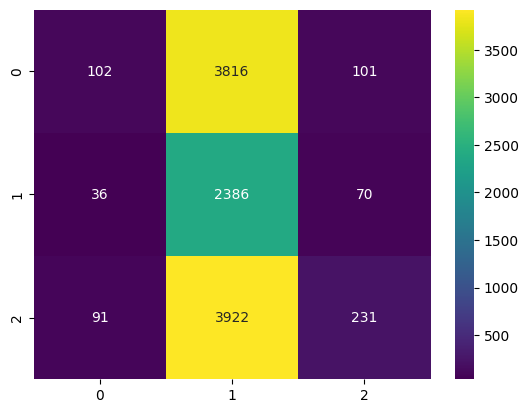

In [682]:
sns.heatmap(heatmap, annot=True, fmt='.0f', cmap='viridis')
print("Daily Precision", df_res[df_res['count'] > 0]['w_p'].mean())
print("Overal precision", (df_res['count_wp'].sum()/df_res['count'].sum()))
print("EV sum", df_res['ev'].sum())
print("Average count", df_res['count'].mean())
print("Active days: ", sum(df_res['count'] > 0) , "/", len(data_set_dict))

## MAX PERCENTILE OF SCORE

## MULTICLASS 

In [296]:
def idx_max_thold(array, thold):
    return pd.Series(array).idxmax() if max(array) > thold else 1

def expected_value(precision, count):
    PROFIT_ = 0.2
    LOSS_ = 0.35
    return (count*precision*PROFIT_)-(count*(1-precision)*LOSS_)

def multivar_model(data_test):
    thold = [0.12, 1.0, 0.15, 0.15]
    cols = ['trd_gap', 'int', 'a_price_sparsity', 'b_price_sparsity']
    feature_increase = [True, True, True, False]
    result = [2 if eval_comb(
        [x[y] for y in cols], thold, feature_increase
    ) else 1 for x in data_test.to_dict(orient='records')]
    return result

def eval_comb(comb, thold, increase_list):
    result = True
    for c, th, inc in zip(comb, thold, increase_list):
        result &= (lambda x, thold, inc: x > thold if inc else x < thold
                       )(c, th, inc)
    return result
    

l_relabel_comb = lambda x: 2 if x > 0.5 else 0 if x < -0.5 else 1

MAX_DEPTH = 5
N_TREES = 4
THOLD = 0.45
SUBSAMPLE = 1
COLSAMPLE = 1
GAMMA = 0
MIN_CH = 0
LAMBDA = 0
ETA = 0.3
xx = {}
y_name = 'y_0.15'
models = []
custom_model = True
heatmap = np.zeros((3,3))
for key, data in data_set_dict.items():
    train = data['train'].copy()
    test = data['test'].copy()
    
    if not custom_model:
        xgb_model_mclass = XGBClassifier(max_depth=MAX_DEPTH, n_estimators=N_TREES, subsample=SUBSAMPLE, colsample_bytree=COLSAMPLE,
                                      gamma=GAMMA, min_child_weight=MIN_CH, reg_lambda=LAMBDA, learning_rate=ETA,
                                         objective="multi:softprob")
        sample_weights = np.where(train[y_name].apply(l_relabel_comb) == 1, 1, 5)
        xgb_model_mclass.fit(train[feature_cols],
                      train[y_name].apply(l_relabel_comb), sample_weight=sample_weights)

        preds_mclass = xgb_model_mclass.predict_proba(test[feature_cols])

        models.append(xgb_model_mclass)


        preds = [idx_max_thold(x, THOLD) for x in preds_mclass]
        
    else:
        preds = multivar_model(test)
    cm = confusion_matrix(test[y_name].apply(l_relabel_comb), preds)
    
    long_TP = cm[2, 2]  # Actual positive (1) and predicted positive (1)
    long_FP = cm[0, 2] + cm[1, 2] # Actual negative (0) but predicted positive (1)

    short_TP = cm[0, 0]  # Actual positive (1) and predicted positive (1)
    short_FP = cm[1, 0] + cm[2, 0] # Actual negative (0) but predicted positive (1)

    neu_TP = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    neu_FP = cm[0, 1] + cm[2, 1] # Actual negative (0) but predicted positive (1)
    
    long_count = long_TP + long_FP
    short_count = short_TP + short_FP
    long_precision = long_TP / long_count if long_count > 0 else 0
    short_precision = short_TP / short_count if short_count > 0 else 0
    neu_precision = neu_TP / (neu_TP + neu_FP) if (neu_TP + neu_FP) > 0 else 0
    
    result = {'p_short': [], 'p_neu': [], 'p_long': [],'count': [], 'count_short': [],'count_long': [], 'ev': [], 'w_p': []}

    result['p_short'].append(short_precision)
    result['p_neu'].append(neu_precision)
    result['p_long'].append(long_precision)
    result['count_short'].append(short_count)
    result['count_long'].append(long_count)
    result['count'].append(long_count+short_count)

    ev = expected_value(long_precision, long_count ) + expected_value(short_precision, short_count)
    result['ev'].append(ev)
    
    result['w_p'].append((long_precision*long_count + short_precision*short_count)/(long_count+short_count) if (long_count+short_count) > 0 else 0)
    

    df_max = pd.DataFrame(result)
    df_max = df_max.iloc[df_max['ev'].idxmax()].to_dict()
    xx[key] = df_max
    heatmap += cm
df_res = pd.DataFrame(xx).T
df_res['count_wp'] = df_res['count']*df_res['w_p']

Daily Precision 0.6662878787878789
Overal precision 0.7521008403361344
EV sum 15.150000000000004
Average count 2.6444444444444444
Active days:  51 / 90


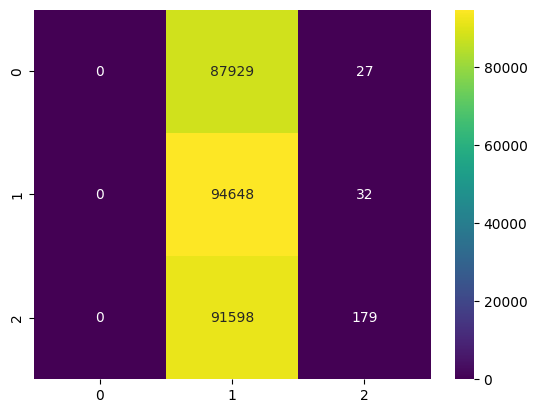

In [297]:
sns.heatmap(heatmap, annot=True, fmt='.0f', cmap='viridis')
print("Daily Precision", df_res[df_res['count'] > 0]['w_p'].mean())
print("Overal precision", (df_res['count_wp'].sum()/df_res['count'].sum()))
print("EV sum", df_res['ev'].sum())
print("Average count", df_res['count'].mean())
print("Active days: ", sum(df_res['count'] > 0) , "/", len(data_set_dict))

In [147]:
booster = models[0].get_booster()
for i, tree_str in enumerate(booster.get_dump()):
    print(f"Tree {i}:\n{tree_str}\n")

Tree 0:
0:[trd_side<1] yes=1,no=2,missing=2
	1:[_far_level<0.350877196] yes=3,no=4,missing=4
		3:[p_movement_1.0<0.00600625016] yes=7,no=8,missing=8
			7:[day<6] yes=15,no=16,missing=16
				15:[diff_am_wm_30<-0.000666320324] yes=31,no=32,missing=32
					31:leaf=0.387985885
					32:leaf=0.211319879
				16:[p_movement_0.5<-0.688899994] yes=33,no=34,missing=34
					33:leaf=0.046911601
					34:leaf=0.212574214
			8:[diff_mw02_05_20<-0.00188313168] yes=17,no=18,missing=18
				17:leaf=-0.225000024
				18:[diff_am_wm_30<-0.00117352582] yes=35,no=36,missing=36
					35:leaf=-0.166810378
					36:leaf=0.367969841
		4:[p_movement_1.0<0.0770062506] yes=9,no=10,missing=10
			9:[day<7] yes=19,no=20,missing=20
				19:[p_movement_1.0<-0.883599997] yes=37,no=38,missing=38
					37:leaf=0.0149258496
					38:leaf=0.159241319
				20:[day<14] yes=39,no=40,missing=40
					39:leaf=-0.0921469256
					40:leaf=0.0966130719
			10:[p_movement_0.3<0.0136111109] yes=21,no=22,missing=22
				21:[day<1] yes=41,no=42,mis

# Predictor analysis

In [116]:
import seaborn as sns

<Axes: xlabel='trd_gap', ylabel='y_0.0'>

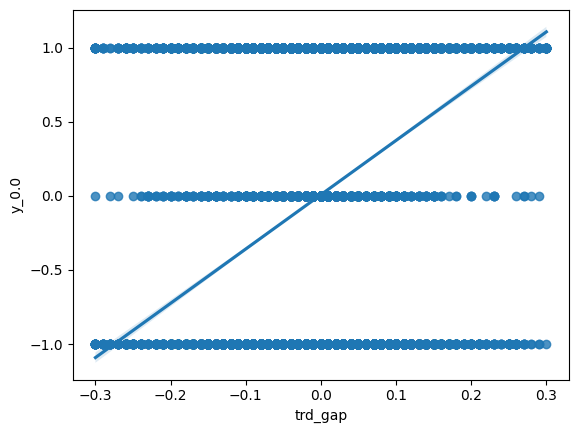

In [118]:
sns.regplot(df_data, x = 'trd_gap', y = 'y_0.0')

In [242]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def idx_max_thold(array, thold):
    return pd.Series(array).idxmax() if max(array) > thold else 1

def expected_value(precision, count):
    PROFIT_ = 0.2
    LOSS_ = 0.35
    return (count * precision * PROFIT_) - (count * (1 - precision) * LOSS_)

def custom_prob(data_test, trd_gap=0.19):
    l_benchmark = lambda x: 2 if x > trd_gap else 0 if x < -trd_gap else 1
    result = [l_benchmark(x['trd_gap']) for x in data_test.to_dict(orient='records')]
    return result

l_relabel_comb = lambda x: 2 if x > 0.5 else 0 if x < -0.5 else 1
l_relabel_long = lambda x: 1 if x > 0.5 else 0

MAX_DEPTH = 1
THOLD = 0.35

xx = {}
y_name = 'y_0.15'
models = []
custom_model = False
heatmap = np.zeros((2, 2))

for key, data in data_set_dict.items():
    train = data['train'].copy()
    test = data['test'].copy()

    if not custom_model:
        dt_model_mclass = DecisionTreeClassifier(max_depth=MAX_DEPTH)
        dt_model_mclass.fit(train[feature_cols], train[y_name].apply(l_relabel_long))

        preds_mclass = dt_model_mclass.predict_proba(test[feature_cols])
        models.append(dt_model_mclass)

        preds = [idx_max_thold(x, THOLD) for x in preds_mclass]
    else:
        preds = custom_prob(test)

    cm = confusion_matrix(test[y_name].apply(l_relabel_long), preds)

    long_TP = cm[1, 1]
    long_FP = cm[0, 1] 

#     short_TP = cm[0, 0]
#     short_FP = cm[1, 0] + cm[2, 0]

#     neu_TP = cm[1, 1]
#     neu_FP = cm[0, 1] + cm[2, 1]

    long_count = long_TP + long_FP
    short_count = 0
    long_precision = long_TP / long_count if long_count > 0 else 0
    short_precision = 0
    neu_precision = 0

    result = {'p_short': [], 'p_neu': [], 'p_long': [], 'count': [], 'count_short': [], 'count_long': [], 'ev': [], 'w_p': []}

    result['p_short'].append(short_precision)
    result['p_neu'].append(neu_precision)
    result['p_long'].append(long_precision)
    result['count_short'].append(short_count)
    result['count_long'].append(long_count)
    result['count'].append(long_count + short_count)

    ev = expected_value(long_precision, long_count) + expected_value(short_precision, short_count)
    result['ev'].append(ev)

    result['w_p'].append((long_precision * long_count + short_precision * short_count) / (long_count + short_count) if (long_count + short_count) > 0 else 0)

    df_max = pd.DataFrame(result)
    df_max = df_max.iloc[df_max['ev'].idxmax()].to_dict()
    xx[key] = df_max
    heatmap += cm

df_res = pd.DataFrame(xx).T
df_res['count_wp'] = df_res['count'] * df_res['w_p']


KeyboardInterrupt: 

Daily Precision 0.4995486993669366
Overal precision 0.500335345405768
EV sum -111.54999999999998
Average count 16.566666666666666
Active days:  4 / 90


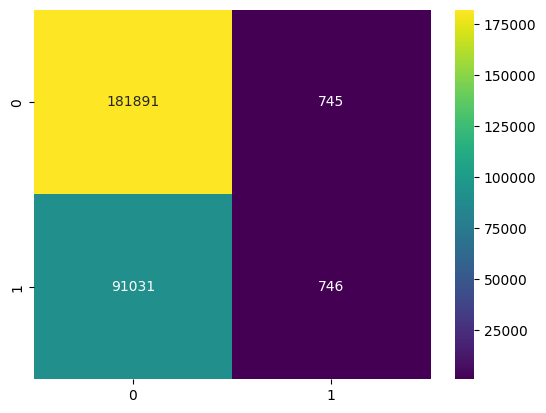

In [225]:
sns.heatmap(heatmap, annot=True, fmt='.0f', cmap='viridis')
print("Daily Precision", df_res[df_res['count'] > 0]['w_p'].mean())
print("Overal precision", (df_res['count_wp'].sum()/df_res['count'].sum()))
print("EV sum", df_res['ev'].sum())
print("Average count", df_res['count'].mean())
print("Active days: ", sum(df_res['count'] > 0) , "/", len(data_set_dict))

In [238]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Export the decision rules
tree_rules = export_text(models[11], feature_names=feature_cols)
print(tree_rules)


|--- trd_gap <= 0.00
|   |--- class: 0
|--- trd_gap >  0.00
|   |--- class: 0



In [274]:
-expected_value(0.62, 1000)

9.0

## read clip board

In [319]:
df_data[['ba_spread', 'delta_mid_05', 'trd_gap', 'a_price_sparsity', 'b_price_sparsity', 'ba_volrat_30', 'int', '_far_level', '_close_level', 'p_movement_0.3', 'p_movement_1.0', 'y_0.15']].to_pickle(r"Z:\Algo_data\reg_data_m.pkl")

In [261]:
df_data.columns

Index(['timestamp', 'y_0.0', 'y_0.15', 'y_0.30', 'delta_a_05', 'delta_a_20',
       'delta_b_05', 'delta_b_20', 'delta_mid_05', 'delta_mid_20',
       'ba_volrat_00', 'ba_volrat_30', 'ba_volrat_50', 'ba_volrat_90',
       'diff_am_wm_00', 'diff_am_wm_30', 'diff_am_wm_50', 'diff_am_wm_90',
       'delta_mw_00_05', 'delta_mw_30_05', 'delta_mw_50_05', 'delta_mw_90_05',
       'delta_mw_00_20', 'delta_mw_30_20', 'delta_mw_50_20', 'delta_mw_90_20',
       'b_price_sparsity', 'a_price_sparsity', 'b_price', 'a_price',
       'diff_mw00_05_20', 'diff_mw01_05_20', 'diff_mw02_05_20', '_close_level',
       '_far_level', 'trd_price', 'trd_side', 'trd_gap', 'last_trade_margin',
       'mid', 'p_movement_0.3', 'p_movement_0.5', 'p_movement_1.0', 'int',
       'day', 'ba_spread'],
      dtype='object')

In [277]:
df_data.to_clip

KeyError: 'y'

<Axes: >

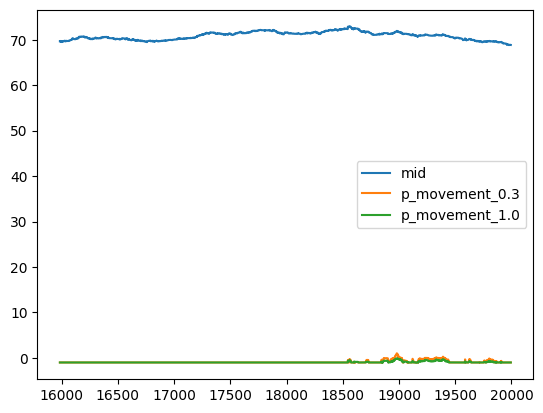

In [301]:
df_data[10000:14000][['mid','p_movement_0.3', 'p_movement_1.0']].plot()

In [311]:
trd, p_03, p_10 = zip(*df_data[14000:15000][['mid','p_movement_0.3', 'p_movement_1.0']].values)

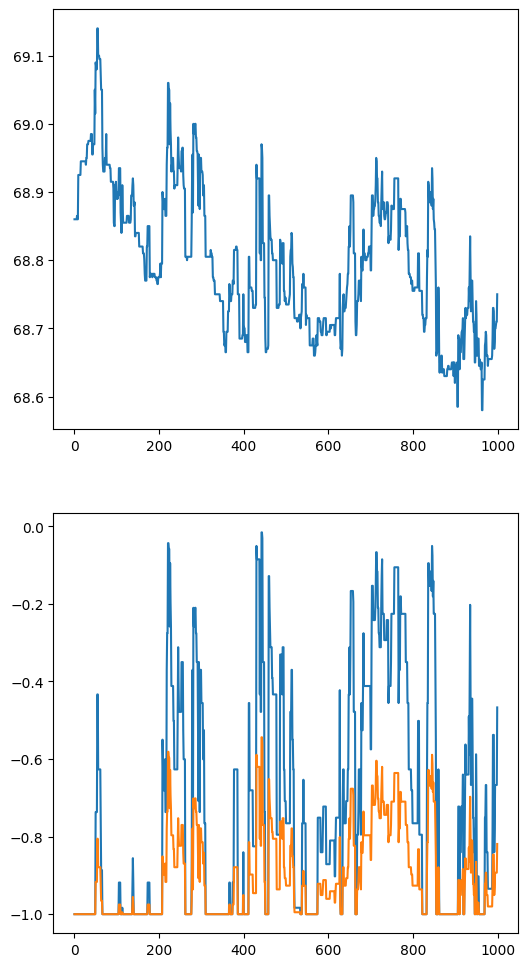

In [312]:
import matplotlib.pyplot as plt

x = np.arange(0, len(trd))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 12))

ax1.plot(x, trd)
ax2.plot(x, p_03)
ax2.plot(x, p_10)

In [313]:
df_data['ba_spread']

5957      0.14
5958      0.33
5959      0.33
5960      0.33
5961      0.33
          ... 
331626    0.18
331627    0.18
331628    0.18
331629    0.13
331630    0.08
Name: ba_spread, Length: 325273, dtype: float64